<a href="https://colab.research.google.com/github/damanpreetsingh1313/Car-Price-Prediction-Model/blob/main/Car_Price_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CAR PRICE PREDICTION MODEL**

##**Filtering Out the Data**

In [49]:
import pandas as pd

df = pd.read_csv('/content/CarPrice_Assignment.csv')

print('First 5 rows of the dataset:')
display(df.head())

print('\nDataFrame Information:')
df.info()

print('\nSummary Statistics for Numeric Columns:')
display(df.describe())



First 5 rows of the dataset:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        20

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### **Data Cleaning and Feature Engineering**

In [50]:
import pandas as pd

df = pd.read_csv('/content/CarPrice_Assignment.csv')

df['CarBrand'] = df['CarName'].apply(lambda x: x.split(' ')[0])

df['CarBrand'] = df['CarBrand'].str.lower()

df['CarBrand'] = df['CarBrand'].replace({
    'maxda': 'mazda',
    'porcshe': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'nissan': 'nissan'
})

df = df.drop(columns=['CarName', 'car_ID','wheelbase','doornumber','carlength','carwidth','carheight','curbweight','enginesize','boreratio','citympg','highwaympg','compressionratio'])

print('Unique Car Brands after cleaning:')
print(df['CarBrand'].unique())
print(f'DataFrame shape after brand extraction and column drops: {df.shape}')

Unique Car Brands after cleaning:
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'buick' 'mercury' 'mitsubishi' 'nissan' 'peugeot' 'plymouth'
 'porsche' 'porcshce' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
DataFrame shape after brand extraction and column drops: (205, 14)


In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**VISUALISATION OF DATA**

##**Correlation Heatmap Visualization**

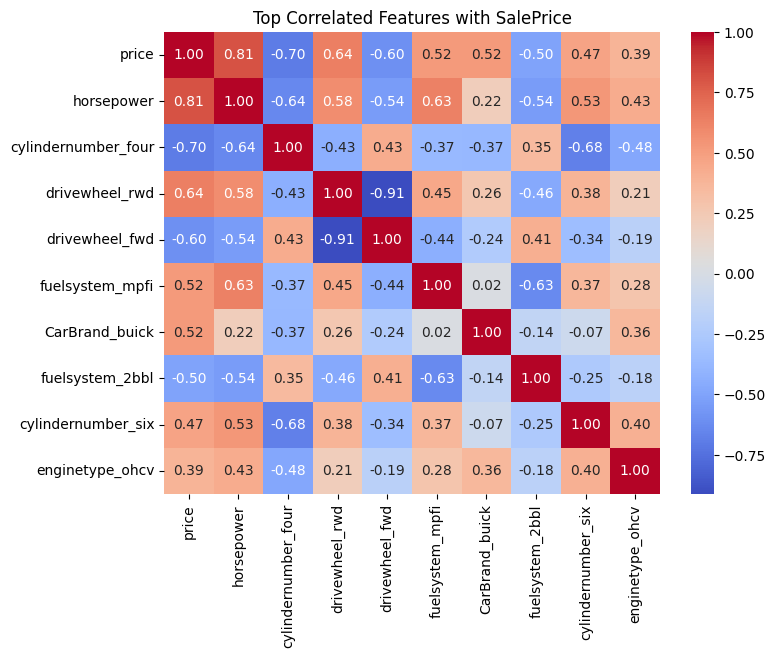

In [52]:
corr = df_encoded.corr()

top_features = corr["price"].abs().sort_values(ascending=False).head(10).index

top_corr = df_encoded[top_features].corr()


plt.figure(figsize=(8, 6))
sns.heatmap(top_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top Correlated Features with SalePrice")
plt.show()

##**Scatter Plot**

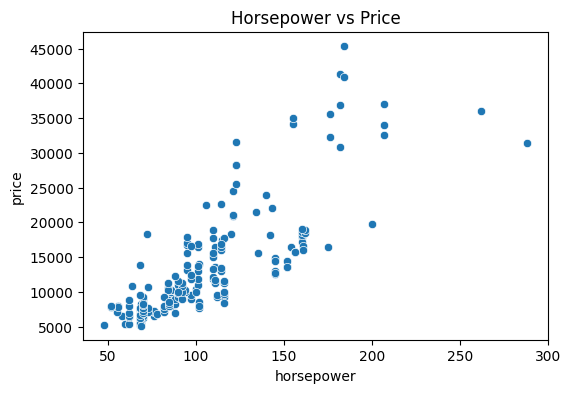

In [53]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df_encoded["horsepower"], y=df_encoded["price"])
plt.title("Horsepower vs Price")
plt.show()

##**Histplot Visualization**

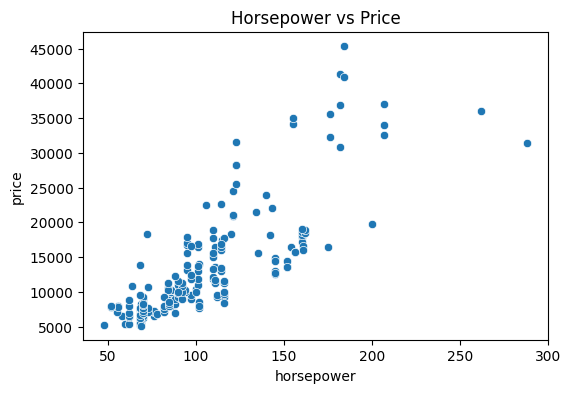

In [54]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df_encoded["horsepower"], y=df_encoded["price"])
plt.title("Horsepower vs Price")
plt.show()

**One-Hot Encoding for Categorical Variables**



In [55]:

categorical_cols = df.select_dtypes(include='object').columns.tolist()


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f'DataFrame shape after one-hot encoding: {df_encoded.shape}')
display(df_encoded.head())

DataFrame shape after one-hot encoding: (205, 55)


,symboling,stroke,horsepower,peakrpm,price,fueltype_gas,aspiration_turbo,carbody_hardtop,carbody_hatchback,carbody_sedan,...,CarBrand_peugeot,CarBrand_plymouth,CarBrand_porcshce,CarBrand_porsche,CarBrand_renault,CarBrand_saab,CarBrand_subaru,CarBrand_toyota,CarBrand_volkswagen,CarBrand_volvo
0,3,2.68,111,5000,13495.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3,2.68,111,5000,16500.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,3.47,154,5000,16500.0,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2,3.40,102,5500,13950.0,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2,3.40,115,5500,17450.0,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


#**Model Training and Evaluation**

##1. **Linear Regression**

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


X = df_encoded.drop('price', axis=1)
y = df_encoded['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


slr = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'\nModel Performance on Test Set:')
print(f'R-squared: {slr:.3f}')
print(f'Mean Absolute Error (MAE): {mae:.3f}')
print(f'Mean Squared Error (MSE): {mse:.3f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.3f}')

Shape of X_train: (164, 54)
Shape of X_test: (41, 54)
Shape of y_train: (164,)
Shape of y_test: (41,)

Model Performance on Test Set:
R-squared: 0.872
Mean Absolute Error (MAE): 2219.972
Mean Squared Error (MSE): 10068647.056
Root Mean Squared Error (RMSE): 3173.113


**Model Visualization**

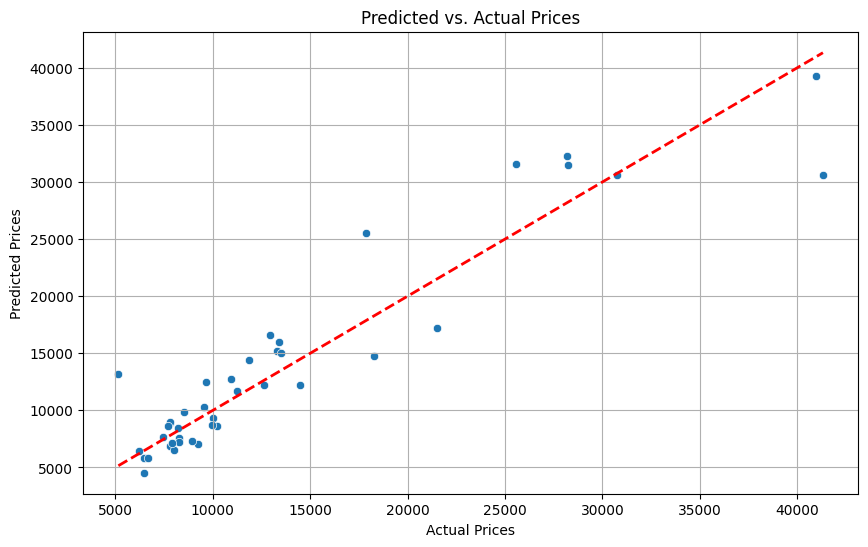

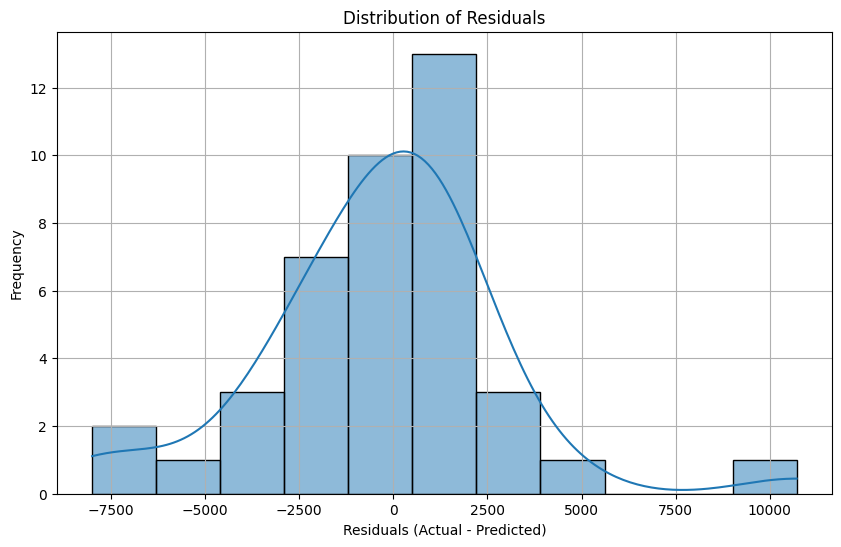

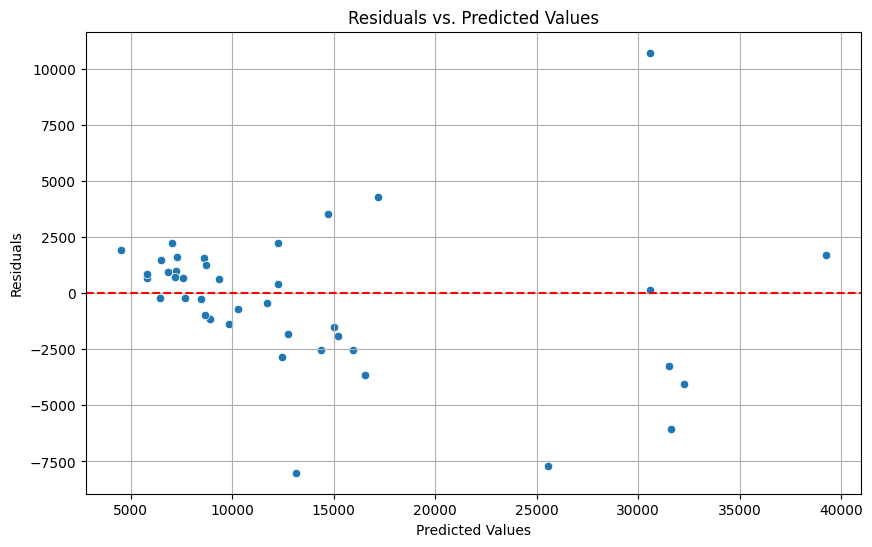

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Predicted vs. Actual Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Predicted vs. Actual Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

# Visualize Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

## **2. Polynomial Regression**

In [58]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

In [59]:
print(X)

     symboling  stroke  horsepower  peakrpm  fueltype_gas  aspiration_turbo  \
0            3    2.68         111     5000          True             False   
1            3    2.68         111     5000          True             False   
2            1    3.47         154     5000          True             False   
3            2    3.40         102     5500          True             False   
4            2    3.40         115     5500          True             False   
..         ...     ...         ...      ...           ...               ...   
200         -1    3.15         114     5400          True             False   
201         -1    3.15         160     5300          True              True   
202         -1    2.87         134     5500          True             False   
203         -1    3.40         106     4800         False              True   
204         -1    3.15         114     5400          True              True   

     carbody_hardtop  carbody_hatchback  carbody_se

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = make_pipeline(
    PolynomialFeatures(degree=4),
    StandardScaler(),
    LinearRegression()
)


pipeline.fit(X_train, y_train)


y_pred2 = pipeline.predict(X_test)


pr = r2_score(y_test, y_pred2)
print(f"R2 Score: {score:.4f}")

R2 Score: 0.9252


In [61]:
from sklearn.metrics import r2_score

mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
print(f'\nModel Performance on Test Set:')
print(f'R-squared: {pr:.3f}')
print(f'Mean Absolute Error (MAE): {mae2:.3f}')
print(f'Mean Squared Error (MSE): {mse2:.3f}')
print(f'Root Mean Squared Error (RMSE): {rmse2:.3f}')


Model Performance on Test Set:
R-squared: 0.925
Mean Absolute Error (MAE): 1871.333
Mean Squared Error (MSE): 5908148.997
Root Mean Squared Error (RMSE): 2430.668


**Model Visualization**

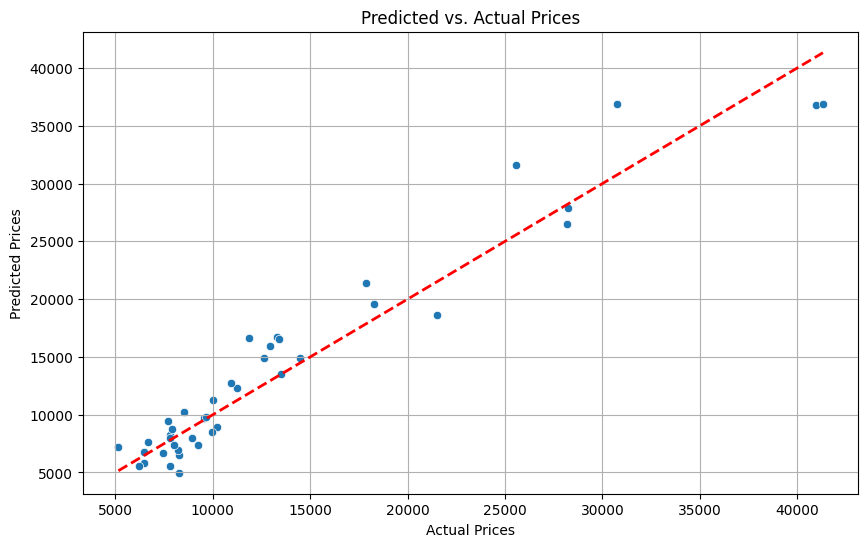

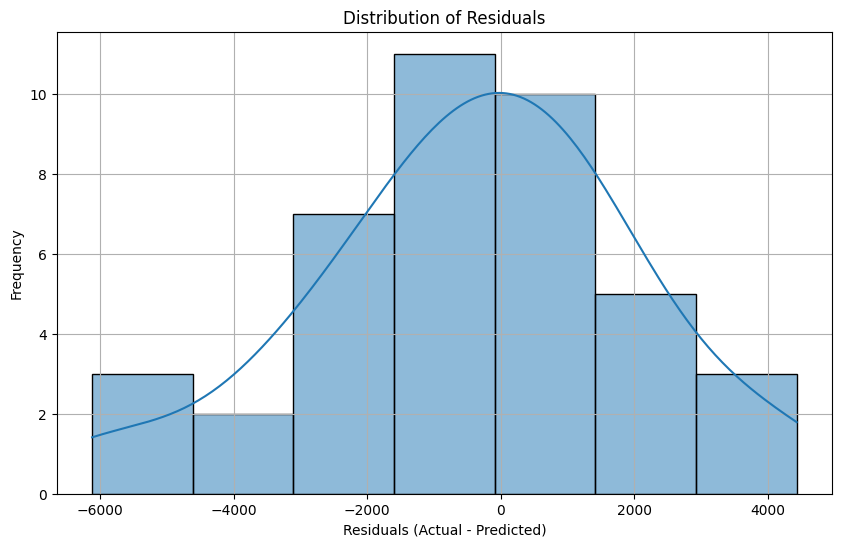

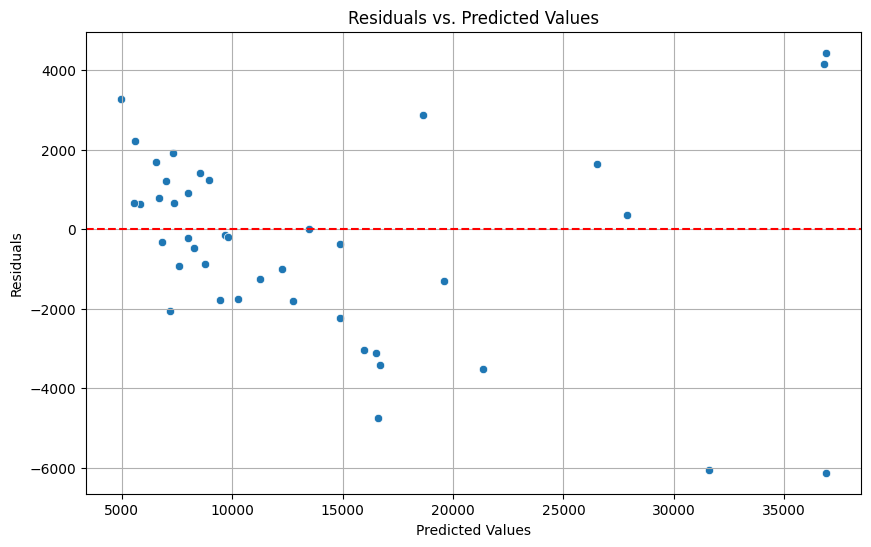

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Predicted vs. Actual Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Predicted vs. Actual Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

# Visualize Residuals
residuals = y_test - y_pred2
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred2, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

## **3. Multiple Linear Regression**

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])],
                       remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [64]:
print(X)

[[0.0 0.0 0.0 ... False False False]
 [0.0 0.0 0.0 ... False False False]
 [0.0 0.0 0.0 ... False False False]
 ...
 [0.0 0.0 0.0 ... False False True]
 [0.0 0.0 0.0 ... False False True]
 [0.0 0.0 0.0 ... False False True]]


In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                    random_state = 0)

In [66]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [67]:
y_pred3 = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred3.reshape(len(y_pred3),1), y_test.values.reshape(len(y_test),1)),1))

[[ 7619.77  6795.  ]
 [17141.52 15750.  ]
 [17011.87 15250.  ]
 [ 6254.4   5151.  ]
 [11193.81  9995.  ]
 [10876.28 11199.  ]
 [ 6013.27  5389.  ]
 [ 6414.79  7898.  ]
 [16145.26 17199.  ]
 [ 6827.77  6529.  ]
 [22840.23 20970.  ]
 [33405.   31400.5 ]
 [12745.   10945.  ]
 [11658.81 18344.  ]
 [ 5390.96  8916.5 ]
 [11352.67  9989.  ]
 [ 7674.18  9295.  ]
 [16753.86 18920.  ]
 [ 8379.72  7895.  ]
 [ 6239.81  6488.  ]
 [ 9874.6   9959.  ]
 [14747.7  15580.  ]
 [ 7161.26  9895.  ]
 [11352.67 11549.  ]
 [17050.52 15998.  ]
 [ 6422.98  5118.  ]
 [ 7719.31  6938.  ]
 [14479.22 16695.  ]
 [ 6958.85  8358.  ]
 [ 7561.8   5499.  ]
 [ 7714.1   7975.  ]
 [ 9883.42 12290.  ]
 [17454.11 22018.  ]
 [11218.31  8948.  ]
 [ 7561.8   6849.  ]
 [32393.49 41315.  ]
 [14220.18 11595.  ]
 [16587.26 18150.  ]
 [ 5609.48  6377.  ]
 [39712.69 45400.  ]
 [ 5380.49  8916.5 ]]


In [68]:
from sklearn.metrics import r2_score
mlr=r2_score(y_test, y_pred3)
mae3 = mean_absolute_error(y_test, y_pred3)
mse3 = mean_squared_error(y_test, y_pred3)
rmse3 = np.sqrt(mse3)
print(f'\nModel Performance on Test Set:')
print(f'R-squared: {mlr:.3f}')
print(f'Mean Absolute Error (MAE): {mae3:.3f}')
print(f'Mean Squared Error (MSE): {mse3:.3f}')
print(f'Root Mean Squared Error (RMSE): {rmse3:.3f}')


Model Performance on Test Set:
R-squared: 0.912
Mean Absolute Error (MAE): 1897.808
Mean Squared Error (MSE): 6807136.128
Root Mean Squared Error (RMSE): 2609.049


**Model Visualization**

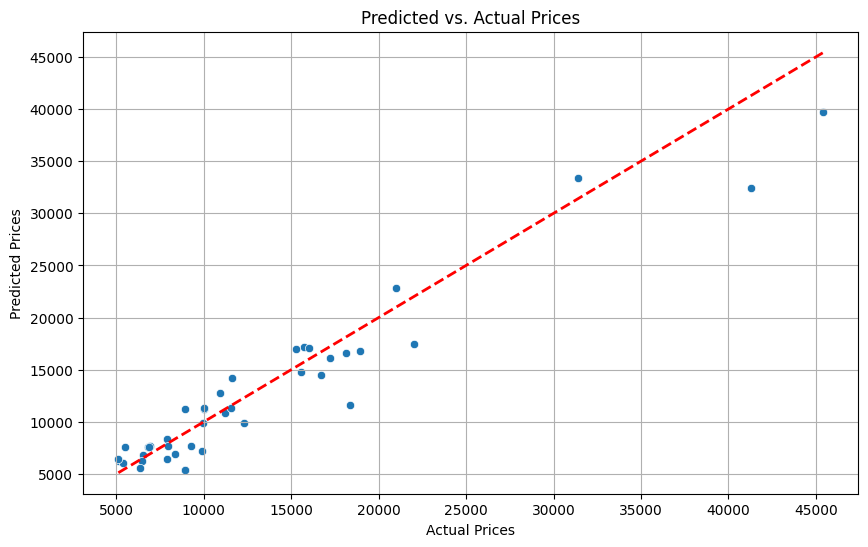

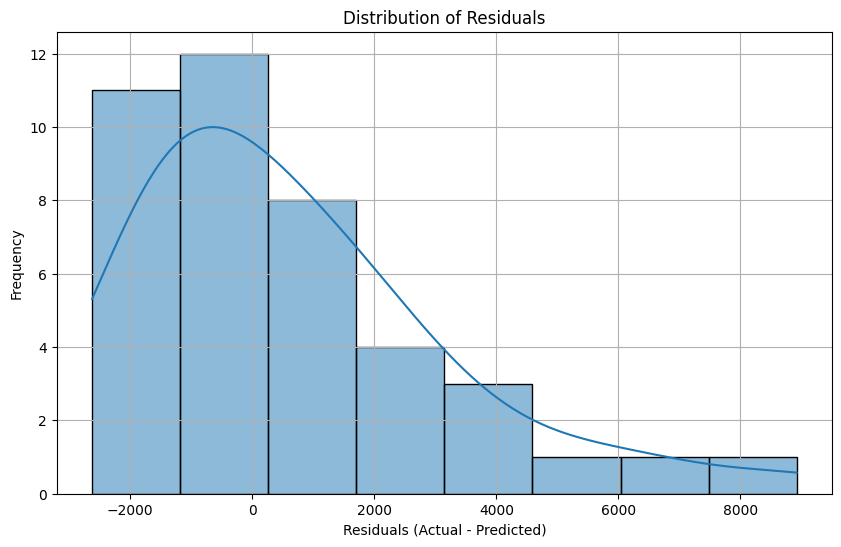

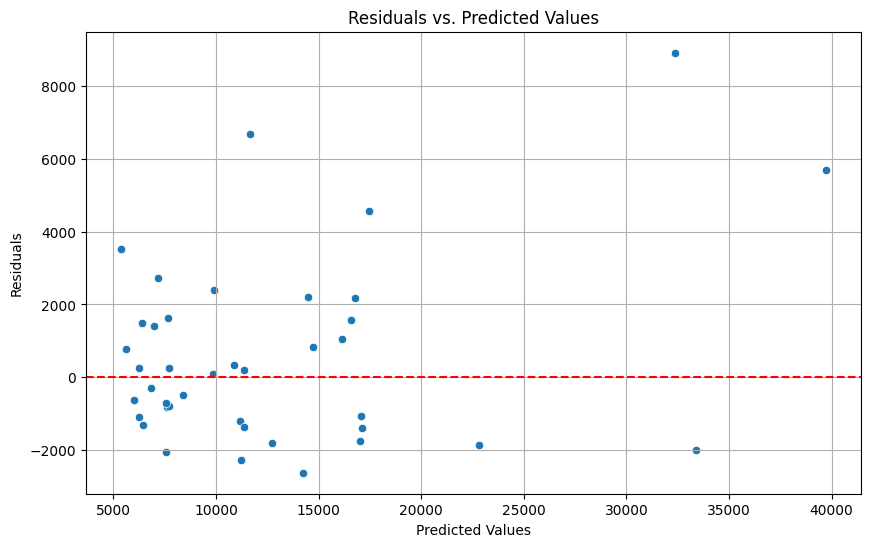

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Predicted vs. Actual Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Predicted vs. Actual Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

# Visualize Residuals
residuals = y_test - y_pred3
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred3, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

##**Comparison between the Models**

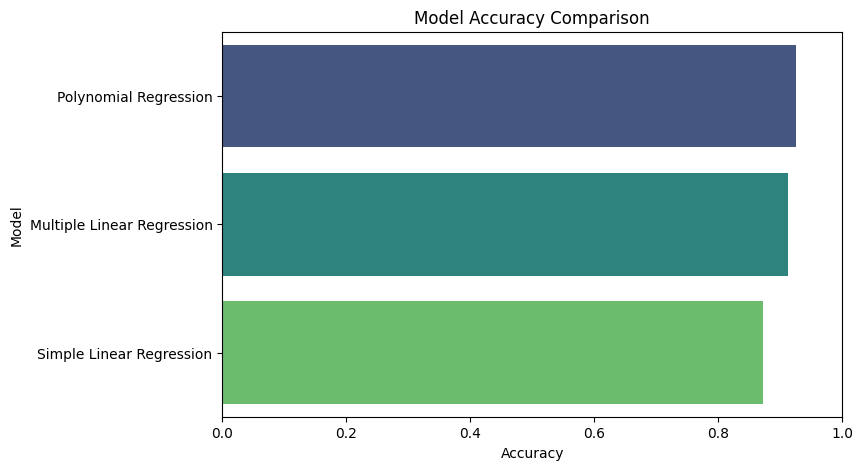

Comparison Table:
                        Model  R-squared  Accuracy
1       Polynomial Regression  -1.024882  0.925160
2  Multiple Linear Regression   0.912071  0.912071
0    Simple Linear Regression  -0.924604  0.872458


In [70]:
results = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Polynomial Regression', 'Multiple Linear Regression'],
    'R-squared': [ r2_score(y_test, y_pred),r2_score(y_test, y_pred2), r2_score(y_test, y_pred3)],

    'Accuracy': [slr, pr, mlr]
})

# Sort by accuracy
results = results.sort_values(by='Accuracy', ascending=False)

# Updated barplot to satisfy new Seaborn requirements
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Accuracy',
    y='Model',
    data=results,
    hue='Model',     # Assign 'Model' to hue for coloring
    palette='viridis',
    legend=False     # Hide the legend since the y-axis already labels the models
)
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1.0)
plt.show()

print("Comparison Table:")
print(results)


In [71]:
best_model_name = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']

print(f"--- FINAL VERDICT ---")
print(f"The best model for predicting student placement is: {best_model_name}")
print(f"Achieved Test Accuracy: {best_accuracy:.2%}")

--- FINAL VERDICT ---
The best model for predicting student placement is: Polynomial Regression
Achieved Test Accuracy: 92.52%
